# Exploring the Bayestar19 3D Dust Map

Interstellar dust dims and reddens starlight. A 2D dust map tells you how much
dust lies in a *direction*. **Bayestar19** (Green et al. 2019) goes one step
further: it tells you how much dust lies between us and a given **distance** in
that direction. It was built from the colors of about 800 million stars with
Pan-STARRS 1, 2MASS, and Gaia distances: a star behind a dust cloud looks redder
than the same kind of star in front of it.

The variable star notebook uses this map in Step 4 to correct a star's
brightness for dust. This notebook lets you look at the map itself.

| Section | Shows | Answers |
|---|---|---|
| 1 | All-sky maps at several distances | Where is the dust, and how does it build up with distance? |
| 2 | One line of sight, from 63 pc to 63 kpc | At what distance does the dust toward my star sit? |
| 3 | A small patch of sky around the target | Is the dust smooth here, or patchy enough to matter? |
| 4 | The Galactic plane seen from above | What does the dust look like in 3D? |
| 5 | Bayestar19 vs. a 2D map | How does the 3D map compare with the classic total-dust map? |

**What the map contains.** The sky is cut into HEALPix pixels (3.4′ to 13.7′
across, finer where there are more stars). Along each pixel's line of sight the map
gives the cumulative reddening at 120 distances, evenly spaced in distance modulus
from 4 to 19 (63 pc to 63 kpc), plus a range of distances where enough stars
constrain it to be **reliable**. It covers declinations north of −30°, the sky
Pan-STARRS could see from Hawaii.

**Units.** Bayestar19 reports reddening in its own units. As in the variable
star notebook, we convert to V-band extinction $A_V$ (magnitudes of dimming in
Johnson V) with $A_V = 2.7476 \times$ the map value. Green et al. (2019) also
give $E(B-V) = 0.884 \times$ the map value.

In [1]:
import astronotebooks
astronotebooks.check_environment()   # stops here, with instructions, if Jupyter is using the wrong Python

import numpy as np
import matplotlib.pyplot as plt

from astronotebooks import catalogs, dust, plots

environment OK


## Settings

Pick any object SIMBAD knows. Leave `DISTANCE_PC = None` to use its Gaia
distance (stars only), or set a distance in parsecs yourself.

The map is a one-time ~700 MB download. If you already ran the variable star
notebook with dust correction, you have it; otherwise uncomment the
`download_bayestar` line and run it once.

In [2]:
TARGET = "XX Cyg"
DISTANCE_PC = None               # None: look up the Gaia distance
DUST_DIR = ".dustmaps_data"      # where the 3D dust map is stored

# dust.download_bayestar(DUST_DIR)    # uncomment and run once (~700 MB)

In [3]:
q = dust.load_bayestar(DUST_DIR)
if q is None:
    raise RuntimeError("The dust map isn't available: see the Settings cell above.")

coord = catalogs.simbad_coords(TARGET)
if DISTANCE_PC is None:
    gaia = catalogs.gaia_distance(TARGET)
    DISTANCE_PC = gaia["d_pc"] if gaia else 1000.0
    print(f"distance: {DISTANCE_PC:.0f} pc " + ("(Gaia DR3, Bailer-Jones)" if gaia else "(no Gaia match: placeholder)"))

g = coord.galactic
print(f"{TARGET}: RA {coord.ra.deg:.3f}°, Dec {coord.dec.deg:+.3f}°  ->  "
      f"Galactic l = {g.l.deg:.1f}°, b = {g.b.deg:+.1f}°")
if coord.dec.deg <= -30:
    print("This target is south of Dec -30°, outside Bayestar19's coverage: sections 2 and 3 will be empty.")

  loading Bayestar19 dust map (first time only, ~30 s) ...
distance: 1126 pc (Gaia DR3, Bailer-Jones)
XX Cyg: RA 300.815°, Dec +58.955°  ->  Galactic l = 92.5°, b = +14.4°


## 1. The whole sky, at four distances

Each panel shows the dust between us and a fixed distance, in **Galactic
coordinates**: the Milky Way's disk runs across the middle ($b = 0°$), the
Galactic center is at the middle of each map ($l = 0°$), and longitude increases
to the left. The gray wedge is the southern sky Pan-STARRS couldn't see.

All four panels share one color scale (logarithmic, because $A_V$ spans more
than two decades). Things to look for:

- At **300 pc** there is already a lot of dust: the nearby molecular clouds
  (Taurus, Ophiuchus, Cepheus, the Aquila Rift) sit within a few hundred
  parsecs and spread far from the plane because they are close.
- By **1–3 kpc** a dark lane builds up along $b = 0°$: the disk itself.
- From **3 to 10 kpc** little changes except in the plane. At high latitude
  the line of sight has already left the dust layer, which is only about
  100–200 pc thick.

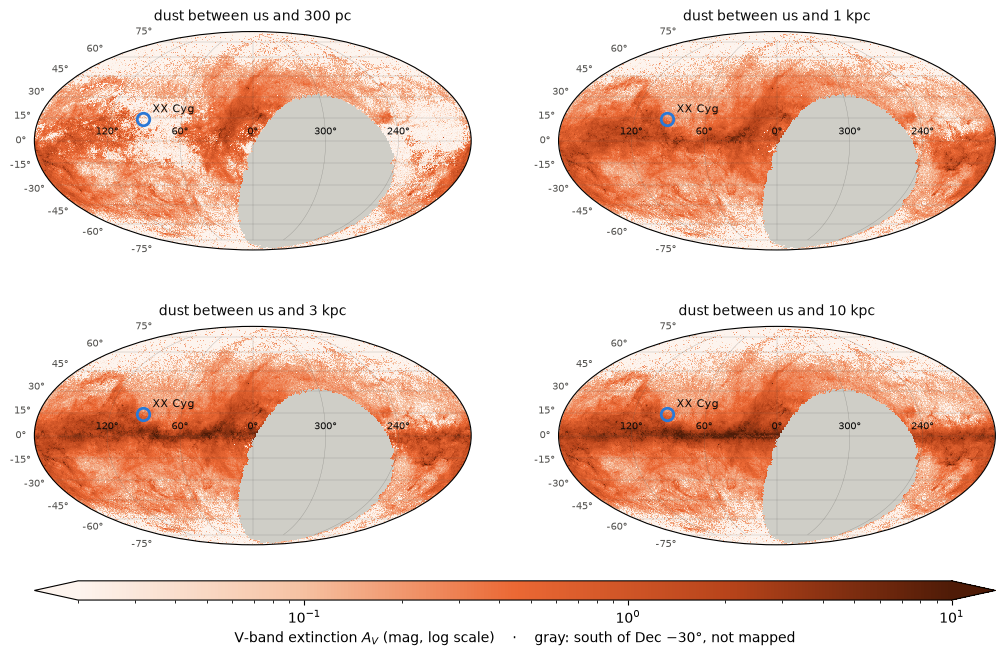

In [4]:
SKY_DISTANCES_PC = [300, 1000, 3000, 10000]

l_grid = np.arange(0, 360, 0.5) + 0.25     # 0.5° cells, centered
b_grid = np.arange(-90, 90, 0.5) + 0.25
sky_maps = {d: dust.sky_grid_av(q, l_grid, b_grid, d) for d in SKY_DISTANCES_PC}

plots.plot_sky_av(l_grid, b_grid, sky_maps, target=coord, target_label=TARGET)
plt.show()

## 2. One line of sight

This is what the variable star notebook reads from the map: the
**cumulative** $A_V$ from the Sun out to each distance toward the target (top), and
how much each distance bin adds (bottom). Steps in the top curve are dust clouds;
flat stretches are clear space.

- The blue band is the 16th–84th percentile of the map's own samples: its
  1σ uncertainty. The variable star notebook uses half its width as the
  error on $A_V$.
- Gray shading marks distances where the map has too few stars to be
  reliable. Nearer than that range, few stars are close enough to see the
  dust; farther, too few are bright enough to measure.
- The dashed line is the target's distance.

Because the map gives $A_V$ as a function of distance, the dust correction and
the distance depend on each other. That's why the variable star notebook
iterates: guess a distance, read $A_V$ there, recompute the distance, repeat.

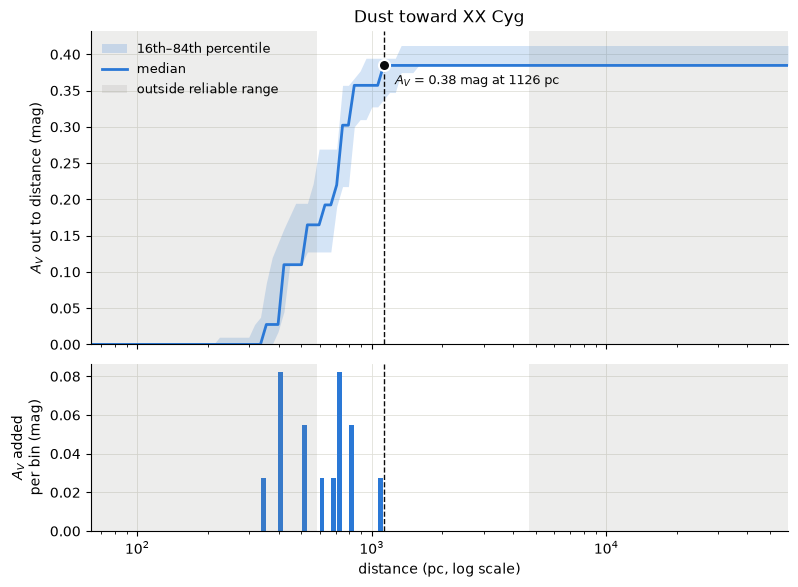

A_V out to 1126 pc: 0.385 ± 0.028 mag
reliable distance range for this sightline: 583 – 4681 pc
A_V out to the edge of the map: 0.385 mag


In [5]:
los = dust.line_of_sight_av(q, coord)
plots.plot_line_of_sight(los, TARGET, DISTANCE_PC)
plt.show()

A_V, A_V_err = dust.bayestar_av(coord, DISTANCE_PC, DUST_DIR)   # the number the variable star notebook uses
r_lo, r_hi = los["reliable_pc"]
print(f"A_V out to {DISTANCE_PC:.0f} pc: {A_V:.3f} ± {A_V_err:.3f} mag")
print(f"reliable distance range for this sightline: {r_lo:.0f} – {r_hi:.0f} pc")
print(f"A_V out to the edge of the map: {los['A_V'][-1, 1]:.3f} mag")

## 3. The sky around the target

The dust at the target's distance, in a small square of sky centered on it.
The blocky texture is the map's pixels (smaller where Pan-STARRS saw more stars).

If the color changes a lot within a pixel or two of the target, the $A_V$ for
your star depends on exactly which pixel it lands in, and the map's quoted
uncertainty may understate the real one.

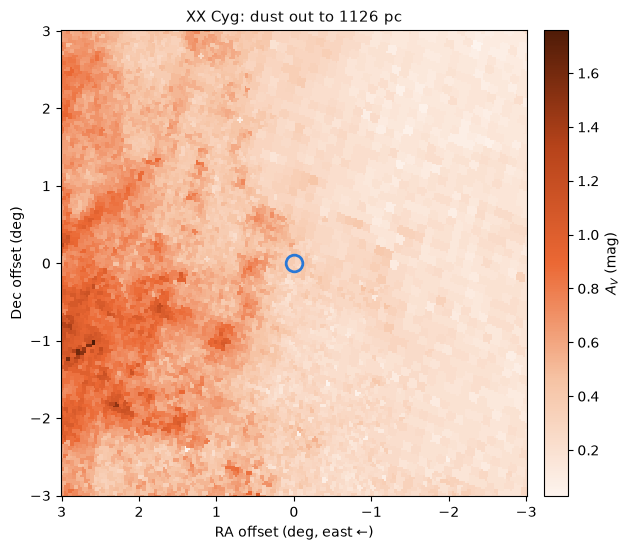

within 15' of XX Cyg: A_V ranges 0.16 – 0.60 mag (spread 0.082 mag 1σ)


In [6]:
FIELD_HALF_WIDTH_DEG = 3.0

offsets, field_av = dust.field_grid_av(q, coord, FIELD_HALF_WIDTH_DEG, DISTANCE_PC)
plots.plot_field_av(offsets, field_av, TARGET, DISTANCE_PC)
plt.show()

near = np.abs(offsets) <= 0.25   # within 15' of the target
patch = field_av[np.ix_(near, near)]
print(f"within 15' of {TARGET}: A_V ranges {np.nanmin(patch):.2f} – {np.nanmax(patch):.2f} mag "
      f"(spread {np.nanstd(patch):.3f} mag 1σ)")

## 4. The Galactic plane, seen from above

This is the 3D part. Imagine looking down on the Milky Way's disk from far above
its north pole, with the Sun at the center. Each direction around the circle is a
Galactic longitude ($l = 0°$, toward the Galactic center, is straight up), and the
distance from the center is the distance from the Sun.

The color is dust **density**: how much $A_V$ each kiloparsec of path adds,
averaged over a thin slab ±1.5° about the plane. Dark knots are individual
clouds; you can see that the dust isn't a uniform fog but clumps and filaments.
The empty wedge on the right is the southern sky, and gray streaks are
sightlines beyond the map's reliable range.

If your target is far from the plane (large $|b|$), its marker is shown at its
longitude and distance, but it sits above or below this slab.

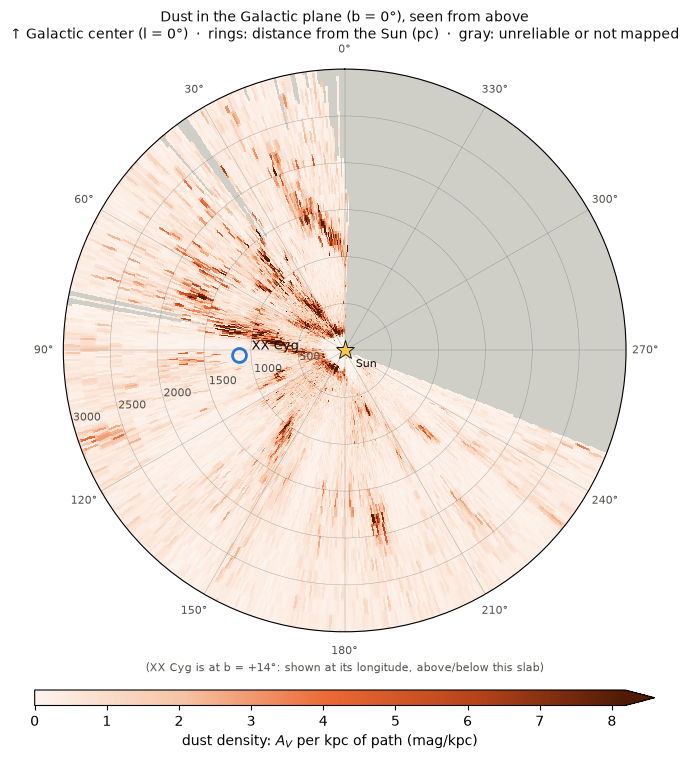

In [7]:
PLANE_B_DEG = 0.0       # try 5 or -5 to slice above or below the plane
PLANE_MAX_PC = 3000

l_plane = np.arange(0, 360, 0.5)
r_edges, plane = dust.plane_density(q, l_plane, b_deg=PLANE_B_DEG, max_pc=PLANE_MAX_PC)
plots.plot_plane_density(l_plane, r_edges, plane, b_deg=PLANE_B_DEG,
                         target=coord, target_label=TARGET, distance_pc=DISTANCE_PC)
plt.show()

## 5. Check: Bayestar19 vs. a 2D dust map

The supernova notebook uses a **2D** map (Schlafly & Finkbeiner 2011, a
recalibration of Schlegel, Finkbeiner & Davis 1998), which measures the *total*
dust in a direction from its far-infrared glow. Bayestar19's cumulative $ at
its far edge is its version of the same total, so the two can be compared
directly (using  = 3.1\,E(B-V)$ for the 2D map).

Don't expect them to match closely. They measure different things, and each has
known blind spots:

- **Bayestar19 needs stars behind the dust.** At very low reddening (high
  Galactic latitude) its fit can bottom out at zero, and where its fit didn't
  converge (the `converged` column) the profile is less trustworthy.
- **The 2D map sees all far-infrared glow in a direction,** including the
  target galaxy's own dust. For a dusty starburst like M82 that inflates the
  "foreground" value.
- **Past its reliable range** (the last column), Bayestar19 just carries the
  last value forward, so any dust beyond that is missing.

For a single star *inside* the Galaxy, only the 3D map can give the dust in
front of it. For a galaxy far outside, the 2D map is the usual choice, which is
why the supernova notebook uses it.

In [8]:
COMPARE = [TARGET, "NGC 7331", "M101", "M82"]

print(f"{'object':12s} {'l':>6s} {'b':>6s}   {'Bayestar19 A_V':>14s}  {'S&F 2011 A_V':>12s}   {'converged':>9s}  {'reliable to':>11s}")
for name in COMPARE:
    c = catalogs.simbad_coords(name)
    ebv = catalogs.milky_way_ebv(name)
    if c is None or ebv is None:
        continue
    l = dust.line_of_sight_av(q, c)
    print(f"{name:12s} {c.galactic.l.deg:6.1f} {c.galactic.b.deg:+6.1f}   "
          f"{l['A_V'][-1, 1]:14.3f}  {3.1 * ebv:12.3f}   {str(l['converged']):>9s}  {l['reliable_pc'][1]:8.0f} pc")

object            l      b   Bayestar19 A_V  S&F 2011 A_V   converged  reliable to


XX Cyg         92.5  +14.4            0.385         0.535        True      4681 pc


NGC 7331       93.7  -20.7            0.330         0.283        True      5889 pc


M101          102.0  +59.8            0.000         0.026       False      3565 pc


M82           141.4  +40.6            0.220         0.484        True      2643 pc


## References

- Green et al. (2019), ApJ 887, 93: the Bayestar19 3D dust map
- Green (2018), JOSS 3, 695: the `dustmaps` Python package
- Schlafly & Finkbeiner (2011), ApJ 737, 103: recalibrated 2D dust map
- Schlegel, Finkbeiner & Davis (1998), ApJ 500, 525: the original 2D dust map
- Interactive Bayestar19 viewer: http://argonaut.skymaps.info/